In [225]:
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt

In [226]:
def beam_element_stiffness(E, I, Le):
    """
    Euler-Bernoulli beam element stiffness matrix.
    DOF ordering: [w1, theta1, w2, theta2]
    """
    return (E * I / Le**3) * np.array([
        [12,        6*Le,       -12,        6*Le],
        [6*Le,      4*Le**2,     -6*Le,      2*Le**2],
        [-12,       -6*Le,       12,        -6*Le],
        [6*Le,      2*Le**2,     -6*Le,      4*Le**2]
    ])

In [227]:
def beam_element_mass(rho, A, Le):
    """
    Consistent mass matrix for an Euler-Bernoulli beam element.
    DOF ordering:[w1, theta1, w2, theta2]
    """
    return (rho * A * Le / 420) * np.array([
        [156,          22*Le,       54,         -13*Le],
        [22*Le,        4*Le**2,     13*Le,       -3*Le**2],
        [54,           13*Le,       156,         -22*Le],
        [-13*Le,      -3*Le**2,    -22*Le,        4*Le**2]
    ])

In [ ]:
E1 = 3E8
E2 = 3E8
Le1 = 1
Le2 = 1
A1 = 1e-2
A2 = 4e-2
I1 = 8.334e-6
I2 = 1.334e-4
rho1 = 7800
rho2 = 7800

In [229]:
K1 = beam_element_stiffness(E1, I1, Le1)
K2 = beam_element_stiffness(E2, I2, Le2)
M1 = beam_element_mass(rho1, A1, Le1)
M2 = beam_element_mass(rho2, A2, Le2)

In [230]:
K_global = np.block([[K1, np.zeros_like(K1)],
                    [np.zeros_like(K2), K2]])

In [231]:
M_global = np.block([[M1, np.zeros_like(M1)],
                    [np.zeros_like(M2), M2]])

In [232]:
T = np.array([[0,0,0,0],
              [0,0,0,0],
              [1,0,0,0],
              [0,1,0,0],
              [0,0,0,0],
              [0,0,0,0],
              [0,0,1,0],
              [0,0,0,1]])

In [233]:
K_constrained = T.T@K_global@T
M_constrained = T.T@M_global@T

In [234]:
eigenvalues, eigenvectors_reduced = eigh(
    K_constrained,
    M_constrained)

In [235]:
eigenvectors_full = T@eigenvectors_reduced

In [236]:
N1 = lambda x,L: 1 - 3*(x/L)**2 + 2*(x/L)**3
N2 = lambda x,L: (x - 2*x**2 + x**3)
N3 = lambda x,L: 3*(x/L)**2 - 2*(x/L)**3
N4 = lambda x,L: -x**2 + x**3

shape_function = lambda x, L: np.array([N1(x, L), N2(x, L), N3(x, L), N4(x, L)])

In [237]:
x = np.linspace(0, Le1, 100)
shape_function(x, Le1).shape

(4, 100)

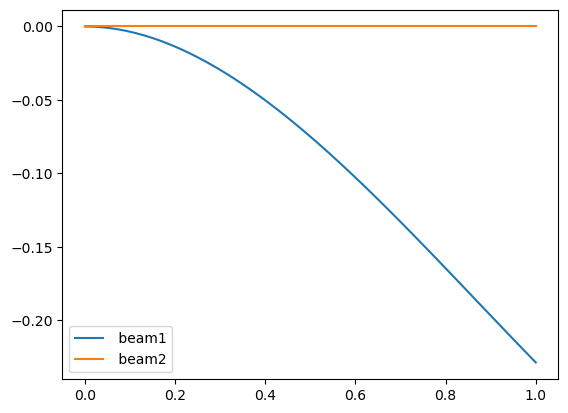

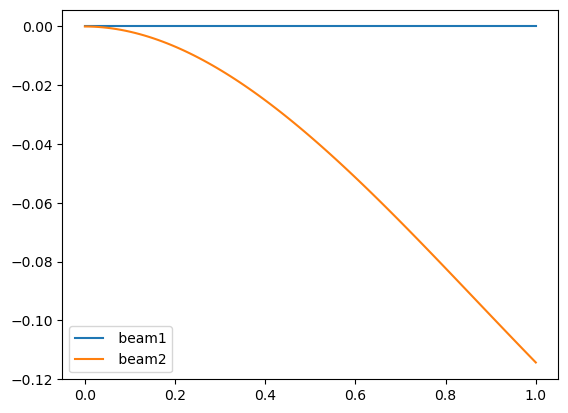

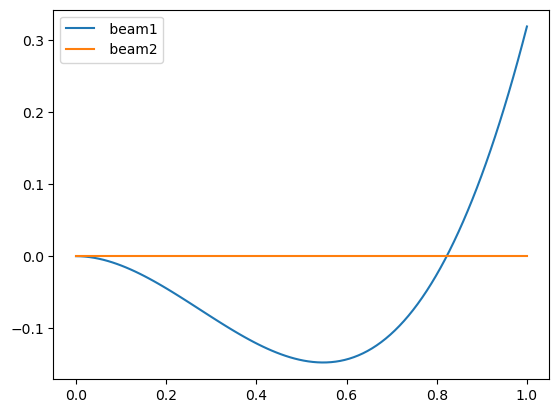

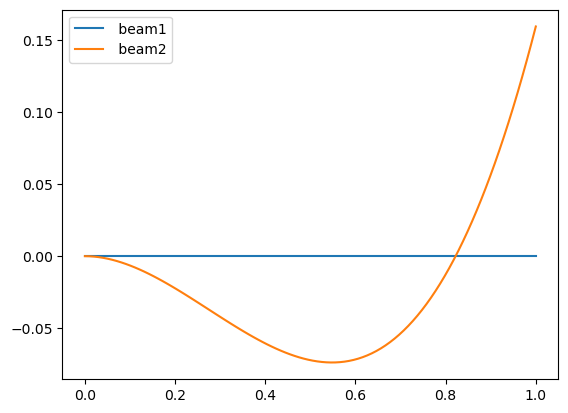

In [238]:
for mode in eigenvectors_full.T:
    phi_1 = mode[0:4]
    phi_2 = mode[4:8]

    x = np.linspace(0,Le1, 100)

    w1 = shape_function(x, Le1).T@phi_1
    w2 = shape_function(x, Le2).T@phi_2

    plt.figure()

    plt.plot(x,w1, label = f" beam1")
    
    plt.plot(x, w2, label = f" beam2" )
    plt.legend()

In [239]:
eigenvectors_full.T@M_global@eigenvectors_full

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        -2.22044605e-16],
       [ 1.38777878e-16,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.38777878e-16,  0.00000000e+00,
         1.00000000e+00]])

In [240]:
eigenvectors_reduced.T@M_constrained@eigenvectors_reduced

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
        -2.22044605e-16],
       [ 2.77555756e-16,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  3.05311332e-16,  0.00000000e+00,
         1.00000000e+00]])

In [241]:
Lambda = np.diag(eigenvalues)

In [ ]:
O = np.zeros_like(Lambda)
Id4 = np.eye(Lambda.shape[1])
zeta = 0.05                          # 2% damping
omega = np.sqrt(eigenvalues)         # natural frequencies (rad/s)

D = np.diag(2*zeta*omega)
A = np.block([[-D,  -Lambda],
              [Id4,  O     ]])

In [243]:
Gamma = -eigenvectors_full.T@M_global

In [244]:
def f(t):
    d2ydt2 = 10*np.sin(9.9*(t**2)/2 + t)
    Yddot = np.array([d2ydt2,0,d2ydt2,0,d2ydt2,0,d2ydt2,0])
    return np.block([Gamma@Yddot, np.zeros(4)])

In [245]:
Id8 = np.eye(8)
a11 = 1/4
a12 = (1/4)-(np.sqrt(3)/6)
a21 = (1/4)+(np.sqrt(3)/6)
a22 = 1/4
c1 = (1/2)-(np.sqrt(3)/6)
c2 = (1/2)+(np.sqrt(3)/6)
b1 = 1/2
b2 = 1/2
h = 0.01

In [246]:
G = np.block([[Id8-a11*h*A, -a12*h*A],[-a21*h*A, Id8-a22*h*A]])
G_inv = np.linalg.inv(G)

In [247]:
def IRK_step(z_n, t_n):
    f1 = f(t_n + c1*h)
    # print(f"f1: {f1.shape}")
    f2 = f(t_n + c2*h)
    Azn = A@z_n
    # print(f"Azn {Azn.shape}")

    R = np.block([Azn + f1 , Azn + f2])
    # print(f"R {R.shape}")
    S = h/2*np.block([Id8 , Id8])
    # print(f"S {S.shape}")
    return z_n + S@G_inv@R

In [248]:
z0 = np.zeros((8), dtype=np.float64)
end_time = 10
n_iter = int(10/h)
zn = z0
tn = 0
eta = np.zeros((4, n_iter+1), dtype= np.float64)
for i in range(n_iter+1):
    eta[:, i] = zn[4:]

    if i < n_iter:
        zn = IRK_step(zn, tn)
        tn += h

In [249]:
x_ts = eigenvectors_full@eta

In [250]:
w_end1 = x_ts[2,:]
w_end2 = x_ts[6,:]

rel_disp = w_end2-w_end1
t = np.arange(n_iter+1)*h

In [251]:
accel = lambda t: 10*np.sin(9.9*(t**2)/2 + t)

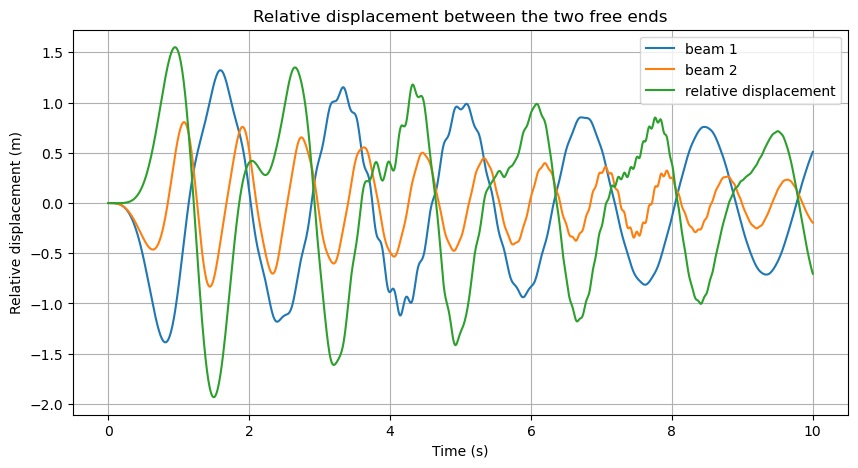

In [252]:
plt.figure(figsize=(10, 5))
#plt.plot(t, accel(t))
plt.plot(t, w_end1, label='beam 1')
plt.plot(t, w_end2, label= 'beam 2')
plt.plot(t, rel_disp, label = 'relative displacement')
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Relative displacement (m)")
plt.title("Relative displacement between the two free ends")
plt.grid(True)
plt.show()

In [253]:
maximum_modal_contribution = eta[:, np.argmax(rel_disp)]

In [254]:
d = np.zeros_like(maximum_modal_contribution)
for i in range(len(maximum_modal_contribution)):
    d[i] = np.abs((eigenvectors_full[6,i]-eigenvectors_full[2,i])*maximum_modal_contribution[i])

In [255]:
relative_modal_contribution = np.zeros_like(eta)

for j in range(4):
    relative_modal_contribution[j, :] = (
        eigenvectors_full[6, j]
        - eigenvectors_full[2, j]
    ) * eta[j, :]

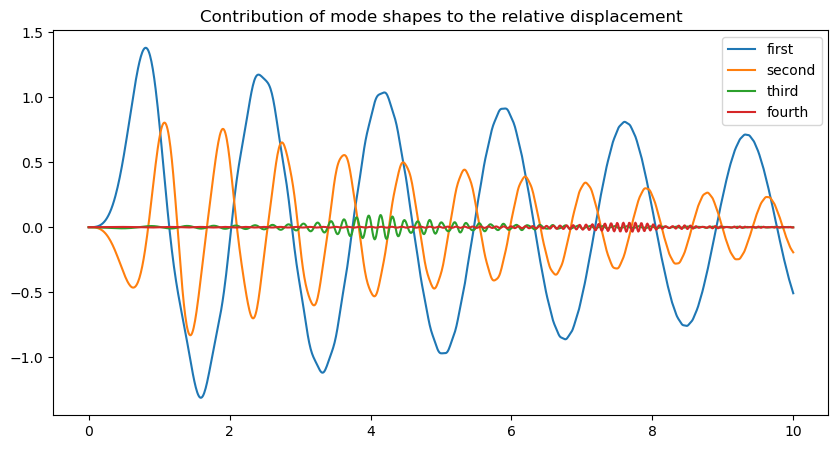

In [256]:
plt.figure(figsize=(10,5))
plt.title("Contribution of mode shapes to the relative displacement")
plt.plot(t, relative_modal_contribution[0], label = 'first')
plt.plot(t, relative_modal_contribution[1], label = 'second')
plt.plot(t, relative_modal_contribution[2],  label = 'third')
plt.plot(t, relative_modal_contribution[3], label='fourth')
plt.legend()